# Task 1: Import and Clean Data

### 1. Import relevant Python libraries for data manipulation and numerical operations:

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

### 2. Load the dataset into a Pandas DataFrame from a CSV file.

In [122]:
df = pd.read_csv('NSMES1988.csv', index_col=0)

### 3. Inspect the data:

In [123]:
# First few rows
print('------ First few rows: ------\n', df.head().to_string())
print('\n')

# Shape
print('------ Shape: ------\n', df.shape)
print('\n')

# column names, and data types
print('------ Column name, data types, check for missing values: ------')
df.info()

------ First few rows: ------
    visits  nvisits  ovisits  novisits  emergency  hospital   health  chronic      adl region  age  gender married  school  income employed insurance medicaid
1       5        0        0         0          0         1  average        2   normal  other  6.9    male     yes       6  2.8810      yes       yes       no
2       1        0        2         0          2         0  average        2   normal  other  7.4  female     yes      10  2.7478       no       yes       no
3      13        0        0         0          3         3     poor        4  limited  other  6.6  female      no      10  0.6532       no        no      yes
4      16        0        5         0          1         1     poor        2  limited  other  7.6    male     yes       3  0.6588       no       yes       no
5       3        0        0         0          0         0  average        2  limited  other  7.9  female     yes       6  0.6588       no       yes       no


------ Shape: -----

### 4. Handle missing values and data inconsistencies:

In [124]:
df.isnull().sum()  # There are no missing values

visits       0
nvisits      0
ovisits      0
novisits     0
emergency    0
hospital     0
health       0
chronic      0
adl          0
region       0
age          0
gender       0
married      0
school       0
income       0
employed     0
insurance    0
medicaid     0
dtype: int64

In [125]:
print('Total missing values: ', df.isnull().sum().sum())


Total missing values:  0


There are no missing values.

In [126]:
# Check for duplicate records and remove them if necessary
df.duplicated().sum()  # None of the records are duplicated

0

There are no duplicate records.

In [127]:
# Almost duplicates:
df['income'].value_counts()
selected = ['income', 'age', 'gender', 'region', 'married', 'employed', 'insurance', 'medicaid', 'school', 'health']
df.loc[df.duplicated(subset=selected, keep=False)].sort_values(by=selected)

,visits,nvisits,ovisits,novisits,emergency,hospital,health,chronic,adl,region,age,gender,married,school,income,employed,insurance,medicaid
2205,1,0,6,0,0,0,average,4,normal,northeast,7.3,female,no,8,0.5183,no,no,yes
2208,8,0,33,1,0,2,average,3,limited,northeast,7.3,female,no,8,0.5183,no,no,yes
4299,7,2,0,0,0,0,poor,1,normal,other,6.6,male,yes,4,0.6636,no,no,yes
4307,6,0,0,0,0,0,poor,5,normal,other,6.6,male,yes,4,0.6636,no,no,yes
2270,0,0,0,0,1,0,average,1,normal,northeast,6.9,female,no,11,0.8040,no,yes,no
2414,3,0,0,0,0,0,average,1,normal,northeast,6.9,female,no,11,0.8040,no,yes,no


As we can see, there are a few rows that have many duplicate column values, which could suggest duplicated data, but there isn't enough evidence to conclude that they are duplicates.

### 5. Comment on data types and suggest optimizations for memory efficiency.

In [128]:
print(df.dtypes)  # Column data types

visits         int64
nvisits        int64
ovisits        int64
novisits       int64
emergency      int64
hospital       int64
health        object
chronic        int64
adl           object
region        object
age          float64
gender        object
married       object
school         int64
income       float64
employed      object
insurance     object
medicaid      object
dtype: object


#### Comments:
- Age: Should probably be an integer.
- Gender: Possible optimization is boolean True/False if there's only 2 options.
- Health: Could be encoded with integers if there are only a certain number of categories like 'average' = 0, 'poor' = -1, and 'excellent' = 1
- Married, employed, insurance, and medicaid: Can be boolean if only options are yes and no.
- Income: If income can include cents like $100.50, it should be a float.
    If it can't include cents, like $100, it should be an integer.
- For any other categorial column like adl, region, and gender, new tables can be created to map unique IDs to all the possible values, and the ID can be used instead of the full word to save space. (Normalization)

### 6. Export the cleaned data as NSMES1988new.csv

In [129]:
df.to_csv('NSMES1988new.csv')

### 7. Write a short report summarizing observations about the data
Report:
- There are no missing values at all.
- 'Age' varies between 6.6 and 10.9 which doesn't make sense in this context.
- 'Income' varies between about -1.01 to 54.84. It is not known what unit this is measuring in, and whether negatives actually make sense.
- 'School' is an integer. It is not known what the integers represent.

Observations about the data:
- About 80% of people are in average health.
- 28.4% of people have 12 as their school, more than any other school.
- 36.6% of people came from region 'other', followed by 26.3% from 'midwest', 19% 'northeast', and 18.1% 'west'.
- Most people have insurance and medicaid, and most are unemployed, suggesting an elderly population.

# Task 2: Data Processing and Statistical Analysis

### 1. Perform transformations:

In [130]:
# Multiply Age by 10
df['age'] *= 10

In [131]:
# Multiply Income by 10,000
df['income'] *= 10_000

### 2. Conduct basic statistical analysis:

In [132]:
# Use describe() function for key columns like Age, Income, and Visits

# Ordinal columns:
print(' --- Ordinal columns: ---')
print(df[['health']].describe().round(2))
print()

# Numerical columns:
print(' --- Numerical columns: ---')
# print(df.select_dtypes(include=['int64', 'float64']).describe().round(2).to_string())
print(df[['visits', 'nvisits', 'ovisits', 'novisits', 'emergency', 'hospital', 'age', 'income', 'chronic']].describe().round(2).to_string())
print()

# Boolean columns:
print(' --- Boolean columns: ---')
print(df[['adl', 'gender', 'married', 'employed', 'insurance', 'medicaid']].describe().round(2))

 --- Ordinal columns: ---
         health
count      4406
unique        3
top     average
freq       3509

 --- Numerical columns: ---
        visits  nvisits  ovisits  novisits  emergency  hospital      age     income  chronic
count  4406.00  4406.00  4406.00   4406.00    4406.00   4406.00  4406.00    4406.00  4406.00
mean      5.77     1.62     0.75      0.54       0.26      0.30    74.02   25271.32     1.54
std       6.76     5.32     3.65      3.88       0.70      0.75     6.33   29246.48     1.35
min       0.00     0.00     0.00      0.00       0.00      0.00    66.00  -10125.00     0.00
25%       1.00     0.00     0.00      0.00       0.00      0.00    69.00    9121.50     1.00
50%       4.00     0.00     0.00      0.00       0.00      0.00    73.00   16981.50     1.00
75%       8.00     1.00     0.00      0.00       0.00      0.00    78.00   31728.50     2.00
max      89.00   104.00   141.00    155.00      12.00      8.00   109.00  548351.00     8.00

 --- Boolean columns: ---
 

### Compare the results with raw dataset statistics
The only difference this dataset has from the original one is that the age and income were multiplied by 10.
No duplicates or missing values were found, so all statistics are the same as the original, except that the age and income statistics are multiplied by 10 and 10,000 respectively.

### 3. Identify columns that are not suitable for statistical analysis and recommend possible datatype changes

In [133]:
df.select_dtypes(include=['object']).dtypes

health       object
adl          object
region       object
gender       object
married      object
employed     object
insurance    object
medicaid     object
dtype: object

Categorical columns are not suitable for statistical analysis because they don't contain numbers. Categorical columns in this dataset:
   * Health
   * Region
   * School (encoded as an integer)

Binary columns:
   * ADL
   * Gender
   * Married
   * Employed
   * Insurance
   * Medicaid

For each categorical column, we could map all of its values to a set of integers to save space. For example, for health, poor could be -1, average 0, and good 1. Or we could create "one hot encoding" columns if there aren't too many categories in each column.

Also, age and income would probably be better as integers.

### 4. Export the processed data to a CSV file named NSMES1988updated.csv

In [134]:
df.to_csv('NSMES1988updated.csv')

### 5. Prepare a short report on statistical observations and insights
- About 80% of people are in average health.
- The ages range from 66 to 109, and the average age is 74, so this dataset focuses on elders.
- 75% of people make less than $32,000, and about 90% are unemployed, so most of these people are probably retired.
- 75% of people only have 2 or fewer chronic conditions.
- The average income is about $25,000 and the median is about $17,000, so the income data is likely right skewed.
- The median age is 73 and the average is 74. Q1 is the median minus 4, and Q2 is median plus 5, so the data for age
    likely looks like a normal distribution.
- There are very large outliers for the visits.
- Emergency visits and hospital days are rare, with over 75% of people never having had one.

# Task 3: Data Analysis with Pandas

### 1. Identify categorical and numerical variables


In [135]:
print('Object data columns: ', list(df.select_dtypes(include='object').columns))

# Note: School is encoded as an integer but is actually categorical data
print('Numerical data columns: ', list(df.select_dtypes(include='number').columns)) 

Object data columns:  ['health', 'adl', 'region', 'gender', 'married', 'employed', 'insurance', 'medicaid']
Numerical data columns:  ['visits', 'nvisits', 'ovisits', 'novisits', 'emergency', 'hospital', 'chronic', 'age', 'school', 'income']


#### Numerical:
* All visits columns, emergency, hospital
* Chronic
* Age
* Income

#### Categorical:
  * Health
   * Region
   * School (encoded as an integer)

Binary categorical columns:
   * ADL
   * Gender
   * Married
   * Employed
   * Insurance
   * Medicaid

### 2. Perform pivoting operations on the dataset based on categorical columns:


In [136]:
# Group by Health and calculate the average healthcare visits
print(' ----- Average amout of visits per health condition -----')
print(df.groupby('health').agg({'visits': 'mean', 'nvisits': 'mean', 'ovisits': 'mean', 'novisits': 'mean', 'emergency': 'mean', 'hospital': 'mean'}).round(1))
print()

# Analyze visit trends across Region
print(' ----- Average amout of visits per region -----')
print(df.groupby('region').agg({'visits': 'mean', 'nvisits': 'mean', 'ovisits': 'mean', 'novisits': 'mean', 'emergency': 'mean', 'hospital': 'mean'}).round(1))

 ----- Average amout of visits per health condition -----
           visits  nvisits  ovisits  novisits  emergency  hospital
health                                                            
average       5.5      1.7      0.7       0.5        0.2       0.3
excellent     3.4      1.6      0.3       0.2        0.1       0.1
poor          8.9      1.4      1.4       0.7        0.6       0.7

 ----- Average amout of visits per region -----
           visits  nvisits  ovisits  novisits  emergency  hospital
region                                                            
midwest       5.4      2.0      0.7       0.6        0.2       0.3
northeast     6.1      1.7      0.8       0.5        0.2       0.3
other         5.6      1.0      0.8       0.6        0.3       0.3
west          6.4      2.3      0.7       0.3        0.3       0.3



### 3. Create distribution tables:


In [137]:
# Healthcare visits distribution by Health
df['all_visits'] = df.visits + df.nvisits + df.ovisits + df.novisits + df.emergency
health_grouped = df.groupby("health")

for col in df:
    if 'visit' in col or col == 'emergency':
        print(f"\n-------- {col} --------")
        print(health_grouped[col].describe().round(2))
        print()




-------- visits --------
            count  mean   std  min  25%  50%   75%   max
health                                                  
average    3509.0  5.51  6.31  0.0  1.0  4.0   8.0  63.0
excellent   343.0  3.43  4.86  0.0  1.0  2.0   5.0  65.0
poor        554.0  8.90  9.12  0.0  3.0  7.0  12.0  89.0


-------- nvisits --------
            count  mean   std  min  25%  50%  75%    max
health                                                  
average    3509.0  1.65  5.09  0.0  0.0  0.0  1.0   78.0
excellent   343.0  1.59  5.92  0.0  0.0  0.0  1.0   66.0
poor        554.0  1.42  6.27  0.0  0.0  0.0  1.0  104.0


-------- ovisits --------
            count  mean   std  min  25%  50%  75%    max
health                                                  
average    3509.0  0.69  3.50  0.0  0.0  0.0  0.0  141.0
excellent   343.0  0.34  1.43  0.0  0.0  0.0  0.0   20.0
poor        554.0  1.38  5.20  0.0  0.0  0.0  1.0   71.0


-------- novisits --------
            count  mean   std  min

In [138]:
# Healthcare visits distribution by Region
region_grouped = df.groupby("region")

for col in df:
    if 'visit' in col or col == 'emergency':
        print(f"\n-------- {col} --------")
        print(region_grouped[col].describe().round(2))
        print()


-------- visits --------
            count  mean   std  min  25%  50%  75%   max
region                                                 
midwest    1157.0  5.41  6.37  0.0  1.0  4.0  7.0  89.0
northeast   837.0  6.09  7.38  0.0  1.0  4.0  8.0  68.0
other      1614.0  5.58  6.59  0.0  1.0  4.0  8.0  66.0
west        798.0  6.37  6.91  0.0  2.0  4.0  9.0  58.0


-------- nvisits --------
            count  mean   std  min  25%  50%  75%    max
region                                                  
midwest    1157.0  1.95  6.12  0.0  0.0  0.0  1.0   78.0
northeast   837.0  1.66  5.62  0.0  0.0  0.0  1.0   71.0
other      1614.0  1.00  4.06  0.0  0.0  0.0  0.0  104.0
west        798.0  2.34  5.83  0.0  0.0  0.0  2.0   66.0


-------- ovisits --------
            count  mean   std  min  25%  50%  75%    max
region                                                  
midwest    1157.0  0.71  2.90  0.0  0.0  0.0  0.0   39.0
northeast   837.0  0.80  4.02  0.0  0.0  0.0  0.0   71.0
other      1


### 4. Encode categorical variables and save data as NSMES1988_Dummy.csv

In [139]:
# Optimizing data types
# df.info()  # Before: 654.0+ KB

# Convert Married, Employed, Insurance, and Medicaid to booleans
bool_equivalents = {'yes': True, 'no': False}
df['married'] = df['married'].map(bool_equivalents)
df['employed'] = df['employed'].map(bool_equivalents)
df['insurance'] = df['insurance'].map(bool_equivalents)
df['medicaid'] = df['medicaid'].map(bool_equivalents)

# Convert health to integer-encoded types
df['health'] = df['health'].map({
    'poor': -1, 
    'average': 0, 
    'excellent': 1
})

# Convert region to integer-encoded types
df['region'] = df['region'].map({
    'other': 0, 
    'midwest': 1, 
    'northeast': 2, 
    'west': 3
})

# Convert male column to boolean
df['gender'] = df['gender'].map({
    'male': True, 
    'female': False
})

# Convert 'adl' column to boolean
df['adl'] = df['adl'].map({
    'normal': True,
    'limited': False
})

# df.info()  # After: 473.3+ KB

In [140]:
print(df.head())

   visits  nvisits  ovisits  novisits  emergency  hospital  health  chronic  \
1       5        0        0         0          0         1       0        2   
2       1        0        2         0          2         0       0        2   
3      13        0        0         0          3         3      -1        4   
4      16        0        5         0          1         1      -1        2   
5       3        0        0         0          0         0       0        2   

     adl  region   age  gender  married  school   income  employed  insurance  \
1   True       0  69.0    True     True       6  28810.0      True       True   
2   True       0  74.0   False     True      10  27478.0     False       True   
3  False       0  66.0   False    False      10   6532.0     False      False   
4  False       0  76.0    True     True       3   6588.0     False       True   
5  False       0  79.0   False     True       6   6588.0     False       True   

   medicaid  all_visits  
1     False 

# Task 4: Data Visualization

### 1. Import visualization libraries (matplotlib, seaborn)

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Select appropriate visualization techniques for the data:

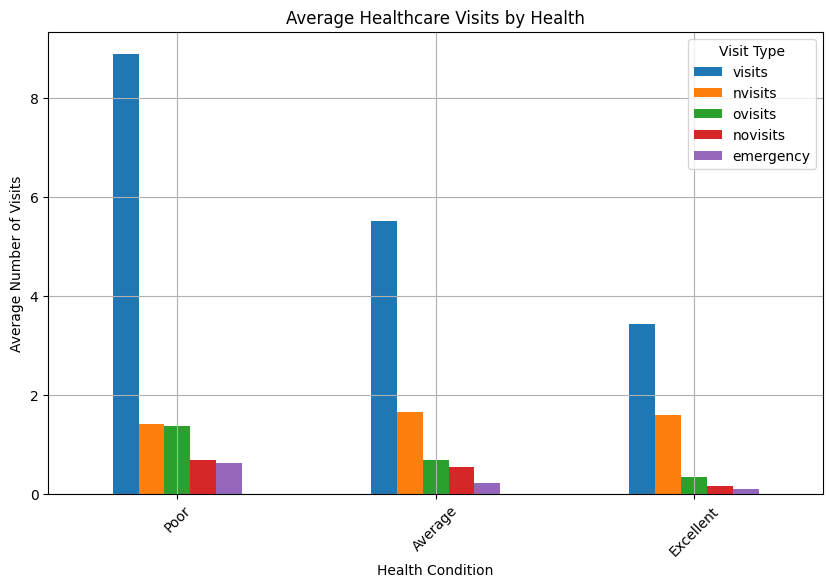

In [154]:
# Bar plot for average healthcare visits by Health
visit_cols = ['visits', 'nvisits', 'ovisits', 'novisits', 'emergency']

# Group by health and get the average number of each type of visit for each health group
health_grouped = df.groupby('health')[visit_cols].mean()

health_grouped.rename(index={
    -1: "Poor",
    0: "Average",
    1: "Excellent"
}).plot(kind="bar", figsize=(10, 6))
plt.grid()
plt.xlabel('Health Condition')
plt.ylabel('Average Number of Visits')
plt.title('Average Healthcare Visits by Health')
plt.xticks(rotation=45)
plt.legend(title='Visit Type')
plt.savefig("healthcare_visits_by_health.png", dpi=300, bbox_inches="tight")
plt.show()


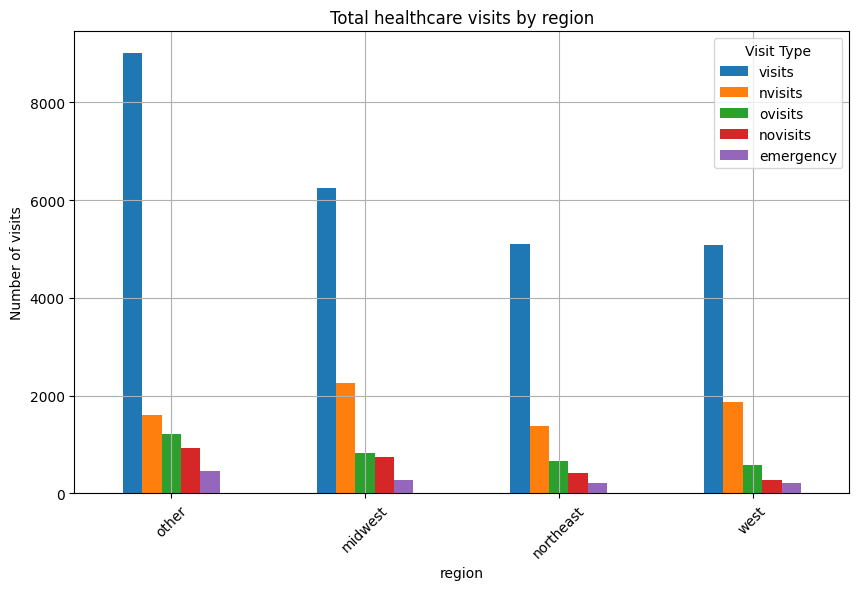

In [143]:
# Bar plot for healthcare visits by Region
region_visits = df.groupby('region')[visit_cols].sum()

region_visits.rename(index={
    0: "other",
    1: "midwest",
    2: "northeast",
    3: "west"
}).plot(kind='bar', figsize=(10,6))
plt.grid()
plt.ylabel('Number of visits')
plt.title('Total healthcare visits by region')
plt.xticks(rotation=45)
plt.savefig("healthcare_visits_by_region.png", dpi=300, bbox_inches="tight")
plt.legend(title='Visit Type')
plt.show()

<Axes: >

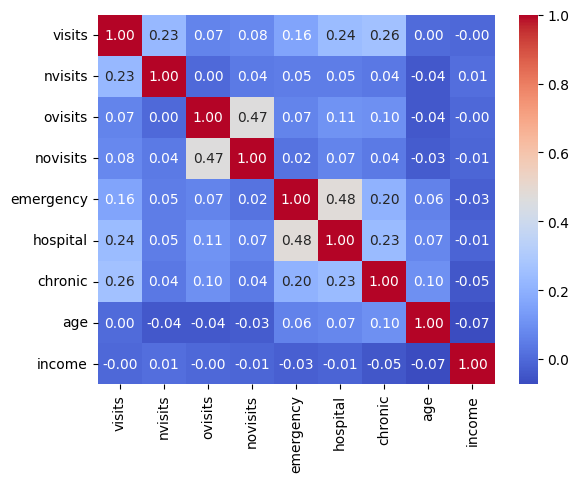

In [144]:
# Heatmap showing correlation among numerical variables
numericals = df[['visits','nvisits','ovisits','novisits','emergency','hospital','chronic','age','income']]
correlation_matrix = numericals.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

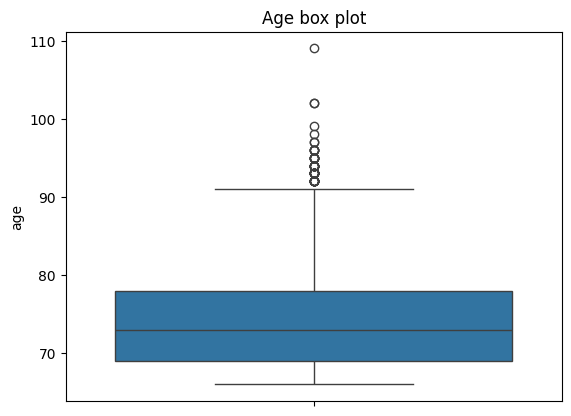

In [151]:
# Box plot to identify outliers in Age, Income, and Visits
ax = sns.boxplot(data=df.age)
ax.set_title('Age box plot')
plt.savefig("boxplot_age.png", dpi=300, bbox_inches="tight")

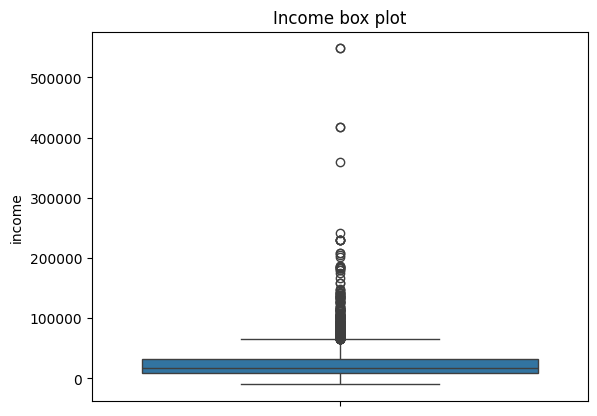

In [ ]:
# Income
ax = sns.boxplot(data=df.income)
ax.set_title('Income box plot')
plt.savefig("boxplot_income.png", dpi=300, bbox_inches="tight")

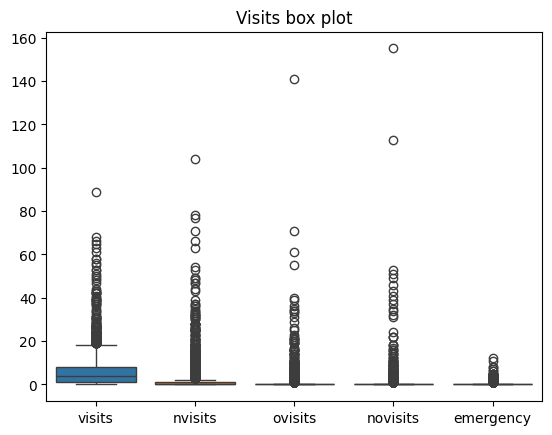

In [ ]:
# Visits
ax = sns.boxplot(data=df[visit_cols])
ax.set_title('Visits box plot')
plt.savefig("boxplot_visits.png", dpi=300, bbox_inches="tight")

### 3. Record observations and insights from visualizations
- The most common type of visit is 'visit', followed by 'nvisit'. The other types of visits are less common.
- The 'Other' region has the most visits, possibly because it is an aggregation of multiple regions. 
- There are few correlations between numerical variables.
    - The most significant ones are (hospital, emergency) and (ovisits, novisits). We can infer that if a patient has spent days in the hospital, then they've had emergency visits, and vice versa. And if they've had ovisits, then they've had novisits and vice versa.
- There are many high outliers for age, income, and visits, so all of these are likely right-skewed distributions.


### 4. Save plots and observations for reporting purposes

Graphs are saved in the cells above using `plt.savefig()` and observations are saved on this notebook.